 **CRAWLING DATA FROM YOUTUBE**

####Mengambil Data dari Youtube

In [ ]:
import googleapiclient.discovery
import pandas as pd

#Mengimpor modul yang diperlukan untuk menggunakan API YouTube dan manipulasi data menggunakan Pandas
api_service_name = "youtube"
api_version = "v3"
DEVELOPER_KEY = "YOUR_YOUTUBE_API_KEY"

#Mendefinisikan nama layanan API YouTube, versi yang akan digunakan, dan kunci pengembang yang diperlukan untuk mengakses API YouTube
youtube = googleapiclient.discovery.build(
    api_service_name, api_version, developerKey=DEVELOPER_KEY)

#Membangun koneksi ke API YouTube menggunakan kredensial pengembang yang telah ditentukan
video_id = "CUCYjMrji-o"
max_results_per_request = 100
total_results_to_fetch = 300

#Menentukan ID video YouTube yang akan diambil komentarnya, jumlah maksimum hasil per permintaan, dan total hasil yang akan diambil
comments = []
next_page_token = None

#Inisialisasi variabel yang diperlukan untuk menyimpan komentar dan token untuk halaman komentar berikutnya
while len(comments) < total_results_to_fetch:
    request = youtube.commentThreads().list(
        part="snippet",
        videoId=video_id,
        maxResults=max_results_per_request,
        pageToken=next_page_token if next_page_token else None
    )
    response = request.execute()
    for item in response['items']:
        comment = item['snippet']['topLevelComment']['snippet']
        comments.append([comment['textDisplay']])
    #Melakukan pengambilan komentar dari respons dan menyimpannya ke dalam list 'comments'
    if 'nextPageToken' in response:
        next_page_token = response['nextPageToken']
    else:
        break

#Mengecek apakah masih ada halaman komentar berikutnya yang perlu diambil atau tidak
hasil_crawling = pd.DataFrame(comments, columns=['comment'])

# Menyimpan DataFrame ke dalam file CSV
hasil_crawling.to_csv('hasil_crawling.csv', index=False)


#Import data csv

In [ ]:
# Import data csv
df = pd.read_csv('hasil_crawling.csv')
df.index = df.index + 1 #agar indexnya dimulai dari 1 bukan 0

from IPython.display import display

# Menampilkan DataFrame untuk dilihat dengan scroll
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,comment
1,Yall voting for him again?
2,Biden will not get my vote.
3,Israel/zion is a colonial proxy. It was create...
4,Stop down right now war Biden
5,This powerful man has every right to say this ...
6,"Bro is so <a href=""http://dumb.how/"">dumb.How<..."
7,"Biden ,Biden come November all the voters will..."
8,Send Biden to Gaza.
9,"Ya ya ya.. now u see, the world is still watch..."
10,I almost feel asleep hearing sleepy joe speaki...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**PRE-PROCESSING DATA**

In [ ]:
# Mengidentifikasi apakah terdapat duplicate value pada tabel
df[df["comment"].duplicated(keep=False)].sort_values("comment")

,comment
20,All we read in history the endless massacres ...
21,All we read in history the endless massacres ...


In [ ]:
# Menghilangkan duplicate value pada tabel
df = df.drop_duplicates(subset=['comment'])
df = df.reset_index(drop=True)
df.index = df.index + 1
df


,comment
1,Yall voting for him again?
2,Biden will not get my vote.
3,Israel/zion is a colonial proxy. It was create...
4,Stop down right now war Biden
5,This powerful man has every right to say this ...
...,...
295,Look at how fast Israel secured their border!!...
296,Poor guy sounds tired 😪 I bet he was up all ni...
297,ДУ Ю СПИК НА РУССКОМ ЯЗЫКЕ<br>АНГЛИЙСКИЙ ХУЖЕ ...
298,I expected this<br> He will have nothing to sa...


In [ ]:
# proses cleansing remove regex (cleansing) seperti tanda baca dan angka angka
import re
import string
def cleansing(Comment):
    Comment = re.sub(r'"http\S+"', '', Comment)
    Comment = re.sub(r'https://\S+', '', Comment)
    Comment = re.sub(r'<a href=>', '', Comment)
    Comment = re.sub(r'<br>', ' ', Comment)
    Comment = re.sub(r'&#39;', '', Comment)
    Comment = re.sub(r'&amp;', '', Comment)
    Comment = re.sub(r'&quot;', '', Comment)
    Comment = re.sub(r'\b(?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday), [a-zA-Z]+ \d{1,2}(st|nd|rd|th), \d{4}@ \d{4}\b', '', Comment)
    Comment = re.sub('[^a-zA-Z]', ' ', Comment)
    Comment = re.sub(r"\b[a-zA-Z]\b", '', Comment)
    Comment = Comment.strip(" ")
    return Comment.lower()
df['cleaned_text'] = df['comment'].apply(lambda x: cleansing(x))

df

,comment,cleaned_text
1,Yall voting for him again?,yall voting for him again
2,Biden will not get my vote.,biden will not get my vote
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...
4,Stop down right now war Biden,stop down right now war biden
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...
...,...,...
295,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...
296,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...
297,ДУ Ю СПИК НА РУССКОМ ЯЗЫКЕ<br>АНГЛИЙСКИЙ ХУЖЕ ...,
298,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...


In [ ]:
# Menghapus baris yang memiliki nilai string kosong (spasi)
df = df[df.apply(lambda x: all(x.str.strip() != ''), axis=1)]

# Reset indeks setelah menghapus baris
df.reset_index(drop=True, inplace=True)
df.index = df.index + 1

df #datanya jadi 1394

,comment,cleaned_text
1,Yall voting for him again?,yall voting for him again
2,Biden will not get my vote.,biden will not get my vote
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...
4,Stop down right now war Biden,stop down right now war biden
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...
...,...,...
289,What an embarrassment,what an embarrassment
290,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...
291,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...
292,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...


In [ ]:
# Menyimpan DataFrame ke file CSV
df.to_csv('data_hasilcleaning.csv', index=False)

**TEXT MINING**

In [ ]:
# Import data csv
df = pd.read_csv('data_hasilcleaning.csv')
df.index = df.index + 1 #agar indexnya dimulai dari 1 bukan 0

df

,comment,cleaned_text
1,Yall voting for him again?,yall voting for him again
2,Biden will not get my vote.,biden will not get my vote
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...
4,Stop down right now war Biden,stop down right now war biden
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...
...,...,...
289,What an embarrassment,what an embarrassment
290,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...
291,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...
292,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Unduh modul punkt, corpus stopwords, dan WordNet Lemmatizer dari NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Fungsi tokenisasi
def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

# Menerapkan fungsi tokenisasi pada kolom 'cleaned_text'
df['tokenized_text'] = df['cleaned_text'].apply(tokenize_text)

df

,comment,cleaned_text,tokenized_text
1,Yall voting for him again?,yall voting for him again,"[yall, voting, for, him, again]"
2,Biden will not get my vote.,biden will not get my vote,"[biden, will, not, get, my, vote]"
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...,"[israel, zion, is, colonial, proxy, it, was, c..."
4,Stop down right now war Biden,stop down right now war biden,"[stop, down, right, now, war, biden]"
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...,"[this, powerful, man, has, every, right, to, s..."
...,...,...,...
289,What an embarrassment,what an embarrassment,"[what, an, embarrassment]"
290,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...,"[look, at, how, fast, israel, secured, their, ..."
291,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...,"[poor, guy, sounds, tired, bet, he, was, up, a..."
292,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...,"[expected, this, he, will, have, nothing, to, ..."


In [ ]:
stop_words

NameError: ignored

In [ ]:
stop_words = set(stopwords.words('english'))

# Fungsi penghapusan stopwords
def remove_stopwords(tokens):
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return filtered_tokens

# Menerapkan penghapusan stopwords pada kolom 'tokenized_text'
df['stopwords_text'] = df['tokenized_text'].apply(remove_stopwords)

# Menampilkan DataFrame dengan hasil penghapusan stopwords
df


,comment,cleaned_text,tokenized_text,stopwords_text
1,Yall voting for him again?,yall voting for him again,"[yall, voting, for, him, again]","[yall, voting]"
2,Biden will not get my vote.,biden will not get my vote,"[biden, will, not, get, my, vote]","[biden, get, vote]"
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...,"[israel, zion, is, colonial, proxy, it, was, c...","[israel, zion, colonial, proxy, created, defia..."
4,Stop down right now war Biden,stop down right now war biden,"[stop, down, right, now, war, biden]","[stop, right, war, biden]"
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...,"[this, powerful, man, has, every, right, to, s...","[powerful, man, every, right, say, israel, per..."
...,...,...,...,...
289,What an embarrassment,what an embarrassment,"[what, an, embarrassment]",[embarrassment]
290,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...,"[look, at, how, fast, israel, secured, their, ...","[look, fast, israel, secured, border, biden, d..."
291,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...,"[poor, guy, sounds, tired, bet, he, was, up, a...","[poor, guy, sounds, tired, bet, night, worryin..."
292,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...,"[expected, this, he, will, have, nothing, to, ...","[expected, nothing, say, palestinians, extermi..."


In [ ]:
# Fungsi lemmatisasi dengan WordNet Lemmatizer
def lemmatize_text(tokens):
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return lemmatized_tokens

# Menerapkan lemmatisasi pada kolom 'stopwords_text'
df['lemmatized_text'] = df['stopwords_text'].apply(lemmatize_text)

# Gabungkan kembali token menjadi teks
df['lemmatized_text'] = df['lemmatized_text'].apply(lambda x: ' '.join(x))

# Menampilkan DataFrame dengan hasil lemmatisasi
df


,comment,cleaned_text,tokenized_text,stopwords_text,lemmatized_text
1,Yall voting for him again?,yall voting for him again,"[yall, voting, for, him, again]","[yall, voting]",yall voting
2,Biden will not get my vote.,biden will not get my vote,"[biden, will, not, get, my, vote]","[biden, get, vote]",biden get vote
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...,"[israel, zion, is, colonial, proxy, it, was, c...","[israel, zion, colonial, proxy, created, defia...",israel zion colonial proxy created defiance in...
4,Stop down right now war Biden,stop down right now war biden,"[stop, down, right, now, war, biden]","[stop, right, war, biden]",stop right war biden
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...,"[this, powerful, man, has, every, right, to, s...","[powerful, man, every, right, say, israel, per...",powerful man every right say israel period sup...
...,...,...,...,...,...
289,What an embarrassment,what an embarrassment,"[what, an, embarrassment]",[embarrassment],embarrassment
290,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...,"[look, at, how, fast, israel, secured, their, ...","[look, fast, israel, secured, border, biden, d...",look fast israel secured border biden doesnt c...
291,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...,"[poor, guy, sounds, tired, bet, he, was, up, a...","[poor, guy, sounds, tired, bet, night, worryin...",poor guy sound tired bet night worrying poor v...
292,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...,"[expected, this, he, will, have, nothing, to, ...","[expected, nothing, say, palestinians, extermi...",expected nothing say palestinian exterminated


#Label TextBlob



In [ ]:
from textblob import TextBlob

In [ ]:
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, text in enumerate(df["lemmatized_text"]):
  analysis = TextBlob(text)
  polaritas = analysis.polarity

  if analysis.sentiment.polarity > 0.0:
    total_positif += 1
    status.append("Positif")
  elif analysis.sentiment.polarity == 0.0:
    total_netral +=1
    status.append("Netral")
  else:
    total_negatif += 1
    status.append("Negatif")

  total += 1

print(f'Hasil Analisis Data:\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}')
print(f'\nTotal Data : {total}')

Hasil Analisis Data:
Positif = 78
Netral = 108
Negatif = 107

Total Data : 293


In [ ]:
# Menambahkan kolom sentimen ke dalam DataFrame
df['Sentimen'] = status
df

,comment,cleaned_text,tokenized_text,stopwords_text,lemmatized_text,Sentimen
1,Yall voting for him again?,yall voting for him again,"[yall, voting, for, him, again]","[yall, voting]",yall voting,Netral
2,Biden will not get my vote.,biden will not get my vote,"[biden, will, not, get, my, vote]","[biden, get, vote]",biden get vote,Netral
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...,"[israel, zion, is, colonial, proxy, it, was, c...","[israel, zion, colonial, proxy, created, defia...",israel zion colonial proxy created defiance in...,Negatif
4,Stop down right now war Biden,stop down right now war biden,"[stop, down, right, now, war, biden]","[stop, right, war, biden]",stop right war biden,Positif
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...,"[this, powerful, man, has, every, right, to, s...","[powerful, man, every, right, say, israel, per...",powerful man every right say israel period sup...,Positif
...,...,...,...,...,...,...
289,What an embarrassment,what an embarrassment,"[what, an, embarrassment]",[embarrassment],embarrassment,Netral
290,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...,"[look, at, how, fast, israel, secured, their, ...","[look, fast, israel, secured, border, biden, d...",look fast israel secured border biden doesnt c...,Negatif
291,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...,"[poor, guy, sounds, tired, bet, he, was, up, a...","[poor, guy, sounds, tired, bet, night, worryin...",poor guy sound tired bet night worrying poor v...,Negatif
292,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...,"[expected, this, he, will, have, nothing, to, ...","[expected, nothing, say, palestinians, extermi...",expected nothing say palestinian exterminated,Negatif


# Visualisasi

akan dipertimbangkan kata yang dihitung dalam wordcloud, untuk melihat pendapat warga dunia sesungguhnya

In [ ]:
norm = {"biden":"", "israel": "", "hamas": "", "people": "", "president": "", "joe":"","yet":"", "really":"","cause":"", "cant":"", "u":"","may":""}

def normalisasi(str_text):
  for i in norm:
    str_text = str_text.replace(i, norm[i])
  return str_text

df["wc"]=df["lemmatized_text"].apply(lambda x:normalisasi(x))
df

,comment,cleaned_text,tokenized_text,stopwords_text,lemmatized_text,Sentimen,wc
1,Yall voting for him again?,yall voting for him again,"[yall, voting, for, him, again]","[yall, voting]",yall voting,Netral,yall voting
2,Biden will not get my vote.,biden will not get my vote,"[biden, will, not, get, my, vote]","[biden, get, vote]",biden get vote,Netral,get vote
3,Israel/zion is a colonial proxy. It was create...,israel zion is colonial proxy it was created...,"[israel, zion, is, colonial, proxy, it, was, c...","[israel, zion, colonial, proxy, created, defia...",israel zion colonial proxy created defiance in...,Negatif,zion colonial proxy created defiance internat...
4,Stop down right now war Biden,stop down right now war biden,"[stop, down, right, now, war, biden]","[stop, right, war, biden]",stop right war biden,Positif,stop right war
5,This powerful man has every right to say this ...,this powerful man has every right to say this ...,"[this, powerful, man, has, every, right, to, s...","[powerful, man, every, right, say, israel, per...",powerful man every right say israel period sup...,Positif,powerfl man every right say period spport di...
...,...,...,...,...,...,...,...
289,What an embarrassment,what an embarrassment,"[what, an, embarrassment]",[embarrassment],embarrassment,Netral,embarrassment
290,Look at how fast Israel secured their border!!...,look at how fast israel secured their border ...,"[look, at, how, fast, israel, secured, their, ...","[look, fast, israel, secured, border, biden, d...",look fast israel secured border biden doesnt c...,Negatif,look fast secred border doesnt care contry ...
291,Poor guy sounds tired 😪 I bet he was up all ni...,poor guy sounds tired bet he was up all nig...,"[poor, guy, sounds, tired, bet, he, was, up, a...","[poor, guy, sounds, tired, bet, night, worryin...",poor guy sound tired bet night worrying poor v...,Negatif,poor gy sond tired bet night worrying poor victim
292,I expected this<br> He will have nothing to sa...,expected this he will have nothing to say abo...,"[expected, this, he, will, have, nothing, to, ...","[expected, nothing, say, palestinians, extermi...",expected nothing say palestinian exterminated,Negatif,expected nothing say palestinian exterminated


In [ ]:
!pip install tweet-preprocessor

In [ ]:
import matplotlib.pyplot as plt

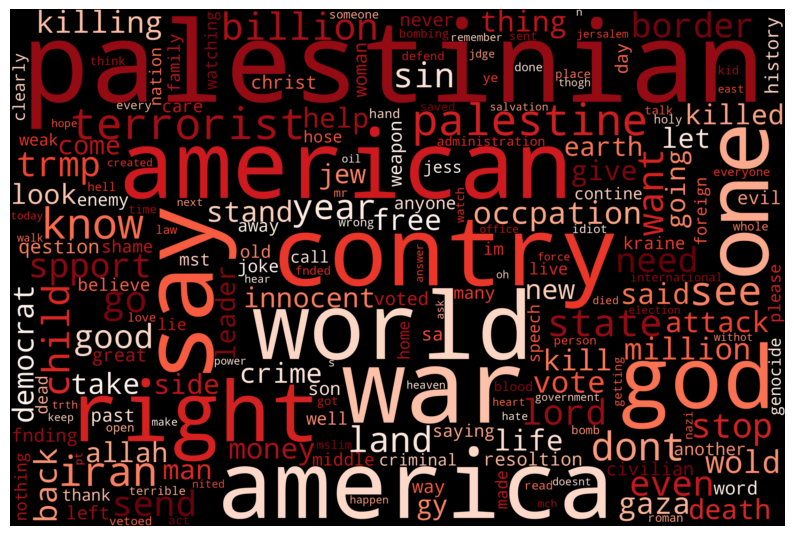

In [ ]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
  plt.figure(figsize=(10,8))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.show()

all_word = ' '.join([tweets for tweets in df['wc']])

wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Reds',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_word)

plot_cloud(wordcloud)

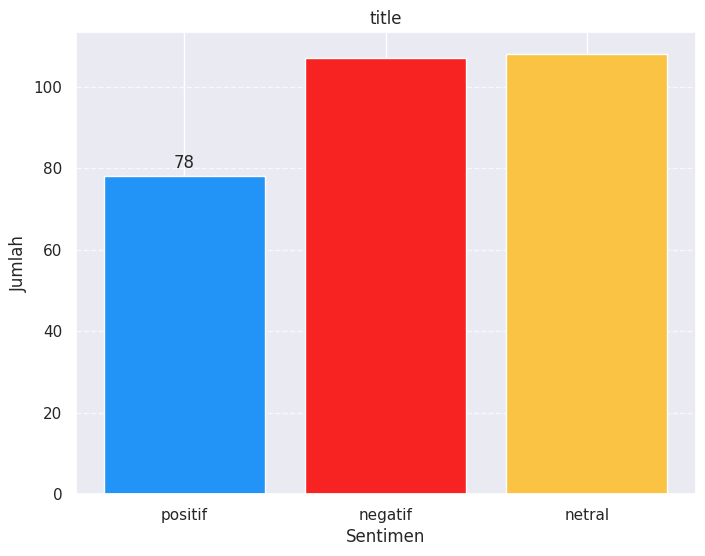

In [ ]:
import seaborn as sns

sns.set_theme()

labels = ['positif', 'negatif', 'netral']
counts = [total_positif, total_negatif, total_netral]

def show_bar_chart(labels, count, tittle):
  fig, ax = plt.subplots(figsize=(8, 6))
  bars = ax.bar(labels, count, color=['#2394f7', '#f72323', '#fac343'])

  for bar, count in zip(bars, count):
    height = bar.get_height()
    ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom')

    ax.grid(axis='y', linestyle='--', alpha=0.7)

    ax.set_xlabel('Sentimen')
    ax.set_ylabel('Jumlah')
    ax.set_title('title')

    plt.show()

show_bar_chart(labels, counts, "Distribusi Sentimen Biden")


**Pelabelan Sentimen dengan VADER**

VADER adalah alat analisis sentimen yang berbasis lexicon dan aturan yang disediakan oleh NLTK (Natural Language Toolkit). VADER memiliki arti Valence Aware Dictionary and sEntiment Reasoner. Alat ini digunakan untuk menganalisis teks dan memberikan skor sentimen pada kata-kata individual dan teks secara keseluruhan, dengan mempertimbangkan konteks dan valensi (tingkat positif atau negatif) dari kata-kata tersebut.

Dalam contoh yang diberikan, VADER digunakan untuk analisis sentimen, yang secara inheren melibatkan metode berbasis lexicon. Skor sentimen yang dihitung oleh VADER didasarkan pada lexicon yang telah dibangun sebelumnya, yang berisi kata-kata dengan polaritas sentimen yang terkait.

In [ ]:
# Fungsi lemmatisasi dengan WordNet Lemmatizer
def lemmatize_text(tokens):
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return lemmatized_tokens

# Menerapkan lemmatisasi pada kolom 'stopwords_text'
df['lemmatized_text'] = df['stopwords_text'].apply(lemmatize_text)

# Menampilkan DataFrame dengan hasil lemmatisasi
df

from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Inisialisasi SentimentIntensityAnalyzer dari NLTK
sid = SentimentIntensityAnalyzer()

# Join lemmatized tokens into a single string
df['lemmatized_text_str'] = df['lemmatized_text'].apply(lambda x: ' '.join(x))

# Hitung sentimen menggunakan VADER pada teks yang sudah di-join
df['sentiment_score'] = df['lemmatized_text_str'].apply(lambda x: sid.polarity_scores(x)['compound'])

# Ambang batas untuk menentukan kategori sentimen
threshold_positive = 0.1
threshold_negative = -0.1

# Fungsi untuk menetapkan label sentimen berdasarkan skor
def categorize_sentiment(score):
    if score >= threshold_positive:
        return 'Positive'
    elif score <= threshold_negative:
        return 'Negative'
    else:
        return 'Neutral'

# Menetapkan label sentimen
df['sentiment_label'] = df['sentiment_score'].apply(categorize_sentiment)

# Tampilkan DataFrame dengan kolom sentimen baru
df

Textblob adalah salah satu library Python untuk melakukan analisis sentimen dengan pendekatan lexicon based. Hasil dari analisis sentimen dengan Textblob akan memberikan output nilai subjectivity dan polarity. Nilai polarity dijadikan sebagai acuan untuk menentukan sentimen suatu data teks masuk ke dalam kategori negatif, netral, atau positif (Sumbernya dari skripsi "Klasifikasi Naive Bayes")

In [ ]:
from textblob import TextBlob
def getSubjectivity(comments):
 return TextBlob(comments).sentiment.subjectivity
def getPolarity(comments):
 return TextBlob(comments).sentiment.polarity
def analyze(score):
 if score < 0:
    return 'Negative'
 elif score == 0:
    return 'Neutral'
 else:
    return 'Positive'
df['Subjectivity'] = df['lemmatized_text'].apply(getSubjectivity)
df['Polarity'] = df['lemmatized_text'].apply(getPolarity)
df['TextBlob'] = df['Polarity'].apply(analyze)

df

In [ ]:
import matplotlib.pyplot as plt

tb_counts = df.Sentimen.value_counts()
tb_counts
plt.figure(figsize=(10, 7))
plt.pie(tb_counts.values, labels=tb_counts.index, explode=(0,0,0.25),
autopct='%1.1f%%', shadow=False)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for i in df.index:
    plt.scatter(df['Polarity'][i], df['Subjectivity'][i], color='blue')

plt.title('Sentiment Analysis')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')
plt.show()

In [ ]:
df = df.astype({'Sentimen' : 'category'})
df = df.astype({'lemmatized_text' : 'string'})
df.dtypes

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer()
text_tf = tf.fit_transform(df['lemmatized_text'].astype('U'))
text_tf

In [ ]:
from sklearn.model_selection import train_test_split
# ukuran 50/50
X_train, X_test, y_train, y_test = train_test_split(text_tf, df['Sentimen'], test_size=0.5, random_state = 42)
# ukuran 60/40
#X_train, X_test, y_train, y_test = train_test_split(text_tf, df['TextBlob'], test_size=0.4, random_state = 42)
# ukuran 70/30
#X_train, X_test, y_train, y_test = train_test_split(text_tf, df['TextBlob'], test_size=0.3, random_state = 42)
# ukuran 80/20
#X_train, X_test, y_train, y_test = train_test_split(text_tf, df['TextBlob'], test_size=0.2, random_state = 42)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

clf = MultinomialNB().fit(X_train, y_train)
predicted = clf.predict(X_test)
print("MultinomialNB accuracy:" , accuracy_score(y_test,predicted))
print("MultinomialNB Precision:" , precision_score(y_test,predicted, average="binary",
pos_label="NEGATIF"))
print("MultinomialNB Recall:" , recall_score(y_test,predicted, average="binary",
pos_label="NEGATIF"))
print("MultinomialNB f1_score:" , f1_score(y_test,predicted, average="binary",
pos_label="NEGATIF"))
print(f'confusion matrix:\n{confusion_matrix(y_test, predicted)}')
print('===============================================\n')
print(classification_report(y_test, predicted, zero_division=0))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

clf = MultinomialNB().fit(X_train, y_train)
predicted = clf.predict(X_test)

print("MultinomialNB accuracy:", accuracy_score(y_test, predicted))
print("MultinomialNB Precision:", precision_score(y_test, predicted, average="weighted"))
print("MultinomialNB Recall:", recall_score(y_test, predicted, average="weighted"))
print("MultinomialNB f1_score:", f1_score(y_test, predicted, average="weighted"))
print(f'confusion matrix:\n{confusion_matrix(y_test, predicted)}')
print('===============================================\n')
print(classification_report(y_test, predicted, zero_division=0, target_names=['class_0', 'class_1', ...]))


**GPT**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
# Bagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(df['lemmatized_text'], df['Sentimen'], test_size=0.5, random_state=42)

In [ ]:
# Proses ekstraksi fitur menggunakan TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
# Inisialisasi model Naive Bayes
naive_bayes_model = MultinomialNB()

# Melatih model Naive Bayes
naive_bayes_model.fit(X_train_tfidf, y_train)

# Melakukan prediksi pada data uji
y_pred = naive_bayes_model.predict(X_test_tfidf)

In [ ]:
# Evaluasi hasil prediksi
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Tampilkan hasil evaluasi
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)

In [ ]:
y_pred = knn_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')


# **BATAASSSSS**

In [ ]:
import re

def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # simbol & piktogram
                               u"\U0001F680-\U0001F6FF"  # transportasi & simbol map
                               u"\U0001F700-\U0001F77F"  # alat & simbol
                               u"\U0001F780-\U0001F7FF"  # Geometri bentuk
                               u"\U0001F800-\U0001F8FF"  # suplai & tanda
                               u"\U0001F900-\U0001F9FF"  # tanda & ikon
                               u"\U0001FA00-\U0001FA6F"  # olahraga & kegiatan
                               u"\U0001FA70-\U0001FAFF"  # makanan & minuman
                               u"\U00002702-\U000027B0"  # dingbat
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r' ', text)
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: remove_emojis(x))

df

In [ ]:
# Fungsi penghapusan stopwords
def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    return ' '.join(filtered_tokens)

# Menerapkan penghapusan stopwords pada kolom 'cleaned_text'
df['stopwords_text'] = df['cleaned_text'].apply(remove_stopwords)

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.corpus import wordnet
nltk.download('stopwords')
nltk.download('punkt')
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: ' '.join([word for word in word_tokenize(x) if word.lower() not in stopwords.words('english')]))

df

In [ ]:
import nltk
nltk.download('stopwords')
#nltk.download('punkt')
stop_words = set(stopwords.words('english'))
df["cleaned_text"] = df["cleaned_text"].apply(lambda x: [word for word in x if word not in stop_words])
df

### **BATASSSS**

In [ ]:
# proses cleansing remove regex (cleansing) seperti tanda baca dan angka angka
import re
import string
def cleansing(Comment):
    Comment = Comment.strip(" ")
    Comment = re.sub(r'[?|$|.|!_:")(-+,]', '', Comment)
    Comment = re.sub(r'\d+', '', Comment)
    Comment = re.sub(r"\b[a-zA-Z]\b", "", Comment)
    Comment = re.sub('\s+',' ', Comment)
    Comment = re.sub('[^a-zA-Z]', ' ', Comment)
    return Comment.lower()
df['cleaned_text'] = df['comment'].apply(lambda x: cleansing(x))
df.head(25)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

#set warning
import warnings
warnings.filterwarnings('ignore')


pd.pandas.set_option('display.max_columns', None)

In [ ]:
df.drop(columns = ['data_name',"data_url"], inplace = True)
df.columns = ['data_review']
df.head()

In [ ]:
df=df.drop_duplicates()
df.head(25)

**PREPROCESSING DATA**

Cleaning Data

In [ ]:
# proses cleansing remove regex (cleansing) seperti tanda baca dan angka angka
import re
import string
def cleansing(Review):
    Review = Review.strip(" ")
    Review = re.sub(r'[?|$|.|!_:")(-+,]', '', Review)
    Review = re.sub(r'\d+', '', Review)
    Review = re.sub(r"\b[a-zA-Z]\b", "", Review)
    Review = re.sub('\s+',' ', Review)
    Review = re.sub('[^a-zA-Z]', ' ', Review)
    return Review.lower()
df['cleaned_text'] = df['data_review'].apply(lambda x: cleansing(x))
df.head(25)

In [ ]:
def tokenize_text(text):
    tokenized_text = text.split()
    return tokenized_text
df['tokens'] = df['cleaned_text'].apply(lambda x: tokenize_text(x))
df.head()